<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/De_los_reyes%2C_Jann_Moisess_Nyll_Hands_on_Activity_3_1_Logistic_Regression_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 3.1 Logistic Regression

#### Objective(s):

This activity aims to solve classification problem using logistic regression

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to train and predict classification model using logistic regression.
* Demonstrate how to evaluate the performance of the logistic regression.
* Demonstrate how to visualize the performance of the logistic regression.

#### Resources:
* Jupyter Notebook
* Titanic





#### Procedure:

Import the libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Load the data using Pandas and check the content of the dataframe

In [ ]:
train = pd.read_csv('/content/titanic_train-1.csv')

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check the missing data.
Use seaborn to create a simple heatmap to see where  are the missing data

<Axes: >

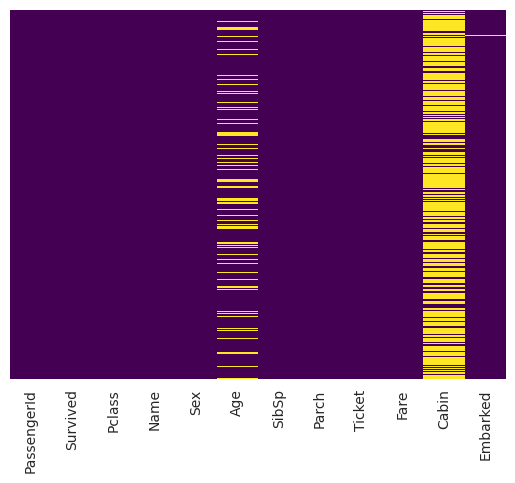

In [ ]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

There are 20% of Age data is missing. We need to replace the missing data with some of imputation.
The Cabin column are also missing too much of that data.

Use data visualization to analyze the data

<ipython-input-10-05742e5567b5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=train,palette='RdBu_r')


<Axes: xlabel='Survived', ylabel='count'>

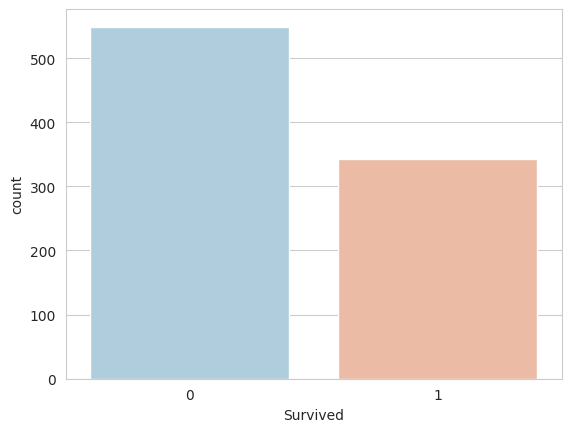

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=train,palette='RdBu_r')

In [ ]:
#count the number of survivors in the dataset
train['Survived'].value_counts()

,count
Survived,
0,549
1,342


Interpret the result of the graph

<font color=green>The total number of survivor in the train dataset are 342 while over 549 died. This mean that over 38% of passengers survived the Titanic Disaster </font>

type your answer here

<Axes: xlabel='Survived', ylabel='count'>

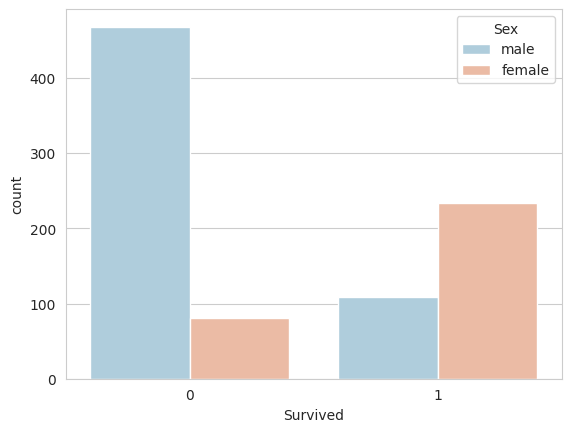

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')

Interpret the result of the graph.

<font color= green>Women had a significantly higher survival rate compared to men. This aligns with the “women and children first” protocol followed during the evacuation.</font>

<Axes: xlabel='Survived', ylabel='count'>

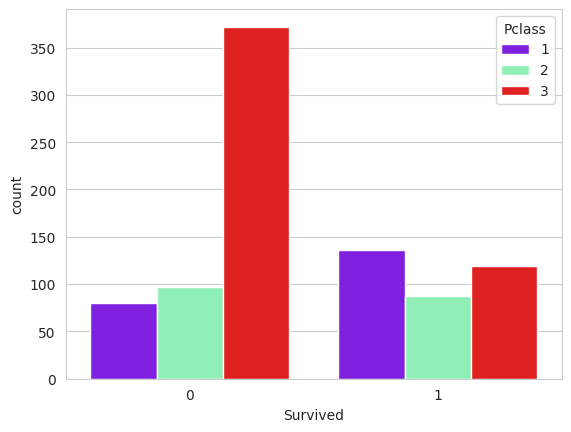

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

Interpret the result.

<font color= green>First-class passengers had a higher survival rate compared to those in second and third class. This reflects the socio-economic disparities in access to lifeboats.<font>

<ipython-input-21-53c281d34688>:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='Age'>

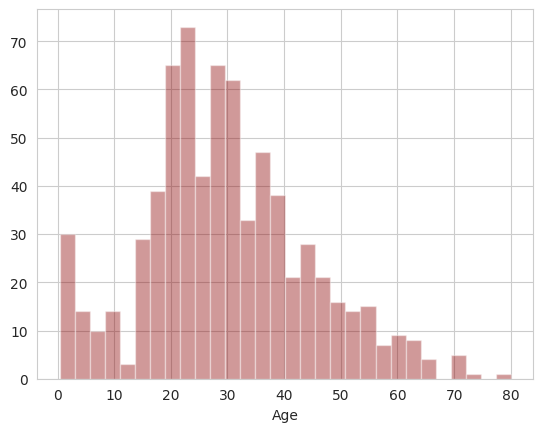

In [ ]:
sns.distplot(train['Age'].dropna(),kde=False,color='darkred',bins=30)

Interpret the result of the graph.

<font color=green>Younger passengers, particularly children, had a higher chance of survival compared to adults.</font>

In [ ]:
import cufflinks as cf
cf.go_offline()

<Axes: ylabel='Frequency'>

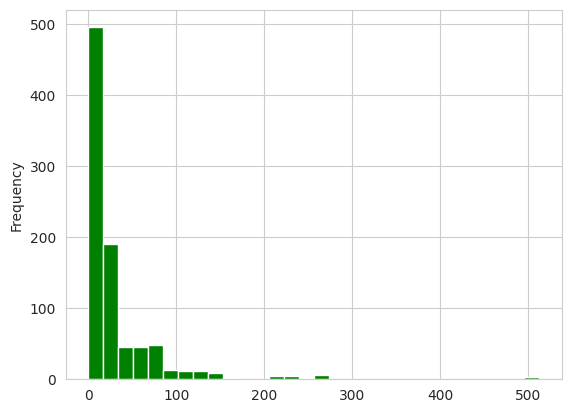

In [ ]:
train['Fare'].plot(kind='hist',bins=30,color='green')

Replace the missing data of the Age column. One way to do this is by filling in the mean age of all the passengers (imputation).


<ipython-input-24-551bc5ec5847>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Pclass', ylabel='Age'>

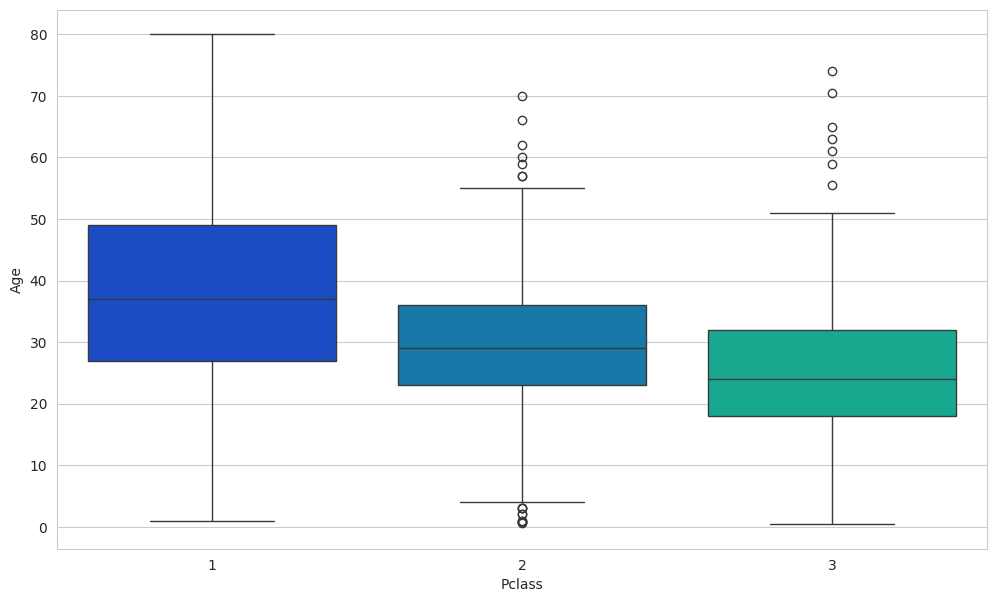

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')

In [ ]:
#create a function to replace the missing data
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37

        elif Pclass == 2:
            return 29

        else:
            return 24

    else:
        return Age

In [ ]:
#apply the function
train['Age'] = train[['Age','Pclass']].apply(impute_age,axis=1)

<ipython-input-25-fd2656a82d91>:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-25-fd2656a82d91>:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<Axes: >

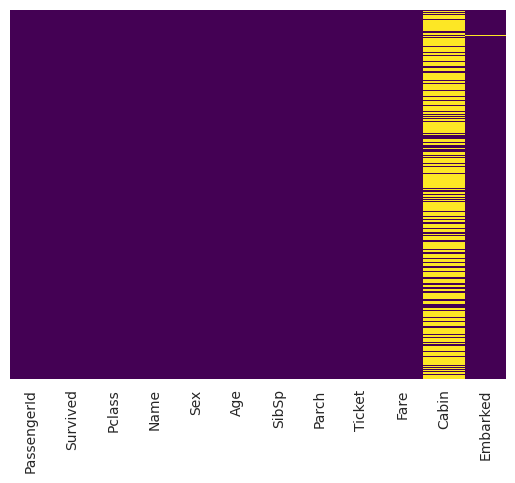

In [ ]:
#check the missing data
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Drop the Cabin column and the row in Embarked that is NaN.

In [ ]:
train.drop('Cabin',axis=1,inplace=True)

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
#drop NaN
train.dropna(inplace=True)

Convert categorical features to dummy variables using pandas

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [ ]:
sex = pd.get_dummies(train['Sex'],drop_first=True)
embark = pd.get_dummies(train['Embarked'],drop_first=True)

In [ ]:
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)
train = pd.concat([train,sex,embark],axis=1)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


Build the Logistic Regression Model

Split the data into a training set and test set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1),
                                                    train['Survived'], test_size=0.30,
                                                    random_state=101)

Train the model

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

Predict the values for the testing data

In [ ]:
predictions = logmodel.predict(X_test)

Check precision,recall,f1-score using classification report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       163
           1       0.81      0.62      0.71       104

    accuracy                           0.80       267
   macro avg       0.80      0.77      0.78       267
weighted avg       0.80      0.80      0.79       267



Interpret the precision, recall f1-score

<font color = green> The provided classification report reveals the performance of the logistic regression model on the Titanic dataset. The model demonstrates strong performance in predicting "Not Survived" (class 0), with high precision and recall. However, it exhibits lower recall for "Survived" (class 1), suggesting potential areas for improvement. The overall accuracy of 80% indicates a decent performance, but further analysis is needed to identify the reasons for the disparity in performance between the two classes.</font>

Evaluate the accuracy and confusion matrix of the model

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [ ]:
print(accuracy_score(y_test, predictions))

0.797752808988764


In [ ]:
confusion_matrix(y_test, predictions)

array([[148,  15],
       [ 39,  65]])

<Axes: xlabel='Predicted', ylabel='Actual'>

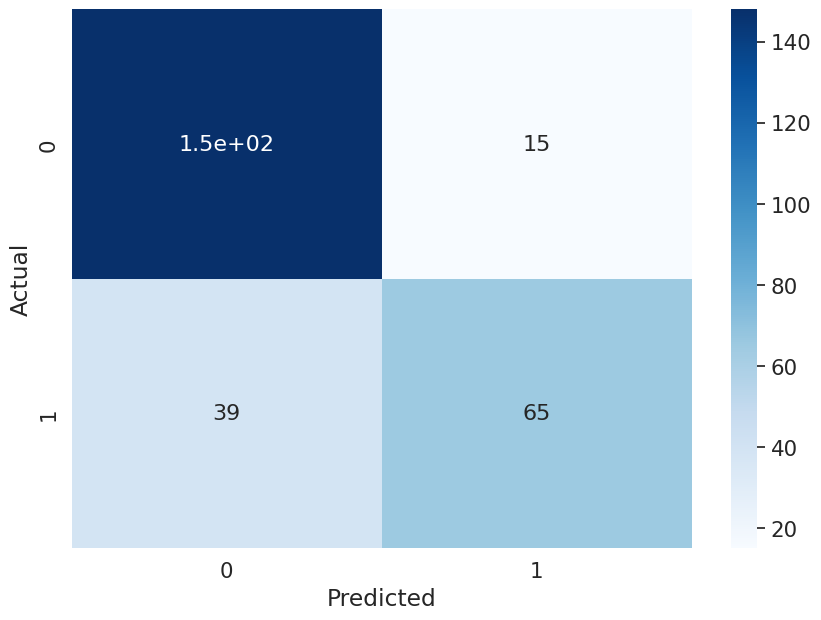

In [ ]:
data = confusion_matrix(y_test, predictions)
df_cm = pd.DataFrame(data, columns=np.unique(y_test), index = np.unique(predictions))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 16})

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Solve classification problem using Logistic Regression
* Evaluate the model using classification report, accuracy and confusion matrix

## About Dataset:
Since real predictive maintenance datasets are generally difficult to obtain and in particular difficult to publish, we present and provide a synthetic dataset that reflects real predictive maintenance encountered in the industry to the best of our knowledge.

The dataset consists of 10 000 data points stored as rows with 14 features in columns

* **UID:** unique identifier ranging from 1 to 10000
* **productID:** consisting of a letter L, M, or H for low (50% of all products), medium (30%), and high (20%) as product quality variants and a variant-specific serial number
* **air temperature [K]:** generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
* **process temperature [K]:** generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
* **rotational speed** [rpm]: calculated from powepower of 2860 W, overlaid with a normally distributed noise
* **torque [Nm]:** torque values are normally distributed around 40 Nm with an Ïƒ = 10 Nm and no negative values.
* **tool wear [min]:** The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process. and a
'machine failure' label that indicates, whether the machine has failed in this particular data point for any of the following failure modes are true.

**Important :** There are two Targets - Do not make the mistake of using one of them as feature, as it will lead to leakage.
* Target : Failure or Not
* Failure Type : Type of Failure

In [ ]:
#upload and transform the csv file to dataframe
defect_df = pd.read_csv('/content/predictive_maintenance.csv')
defect_df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure


In [ ]:
# Determine the number of datapoints, columns and data types
defect_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
#change column name of the dataframe
defect_df.columns = ['UID', 'productID','type', 'airtemperature', 'processtemperature', 'rotationalspeed', 'torque', 'toolwear', 'Target', 'FailureType']
defect_df.head()

,UID,productID,type,airtemperature,processtemperature,rotationalspeed,torque,toolwear,Target,FailureType
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


Remove unneccesary columns


In [ ]:
defect_df['FailureType'].unique()

array(['No Failure', 'Power Failure', 'Tool Wear Failure',
       'Overstrain Failure', 'Random Failures',
       'Heat Dissipation Failure'], dtype=object)

In [ ]:
#In this activity we will not idenfity the type of failure does we need to remove this column
defect_df.drop(['FailureType','UID','productID'], axis=1, inplace=True)
defect_df.head()

,type,airtemperature,processtemperature,rotationalspeed,torque,toolwear,Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


Do data cleaning such as removing empty values(NaN), replacing missing data .

In [ ]:
#remove empty values
defect_df.dropna(inplace=True)


In [ ]:
#replace missing data
defect_df.isnull().sum()

,0
type,0
airtemperature,0
processtemperature,0
rotationalspeed,0
torque,0
toolwear,0
Target,0


In [ ]:
#before we proceed to descriptive statistics we need to perform featured engineering for type column
defect_df['type'].unique()

array(['M', 'L', 'H'], dtype=object)

In [ ]:
# change the unique valuesof type columns into numerical values using get dummies
defect_df = pd.get_dummies(defect_df, columns=['type'])
defect_df.head()

,airtemperature,processtemperature,rotationalspeed,torque,toolwear,Target,type_H,type_L,type_M
0,298.1,308.6,1551,42.8,0,0,False,False,True
1,298.2,308.7,1408,46.3,3,0,False,True,False
2,298.1,308.5,1498,49.4,5,0,False,True,False
3,298.2,308.6,1433,39.5,7,0,False,True,False
4,298.2,308.7,1408,40.0,9,0,False,True,False


In [ ]:
#perform descriptive statistics such as mean median and mode
defect_df.describe()

,airtemperature,processtemperature,rotationalspeed,torque,toolwear,Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


 Perform data visualization

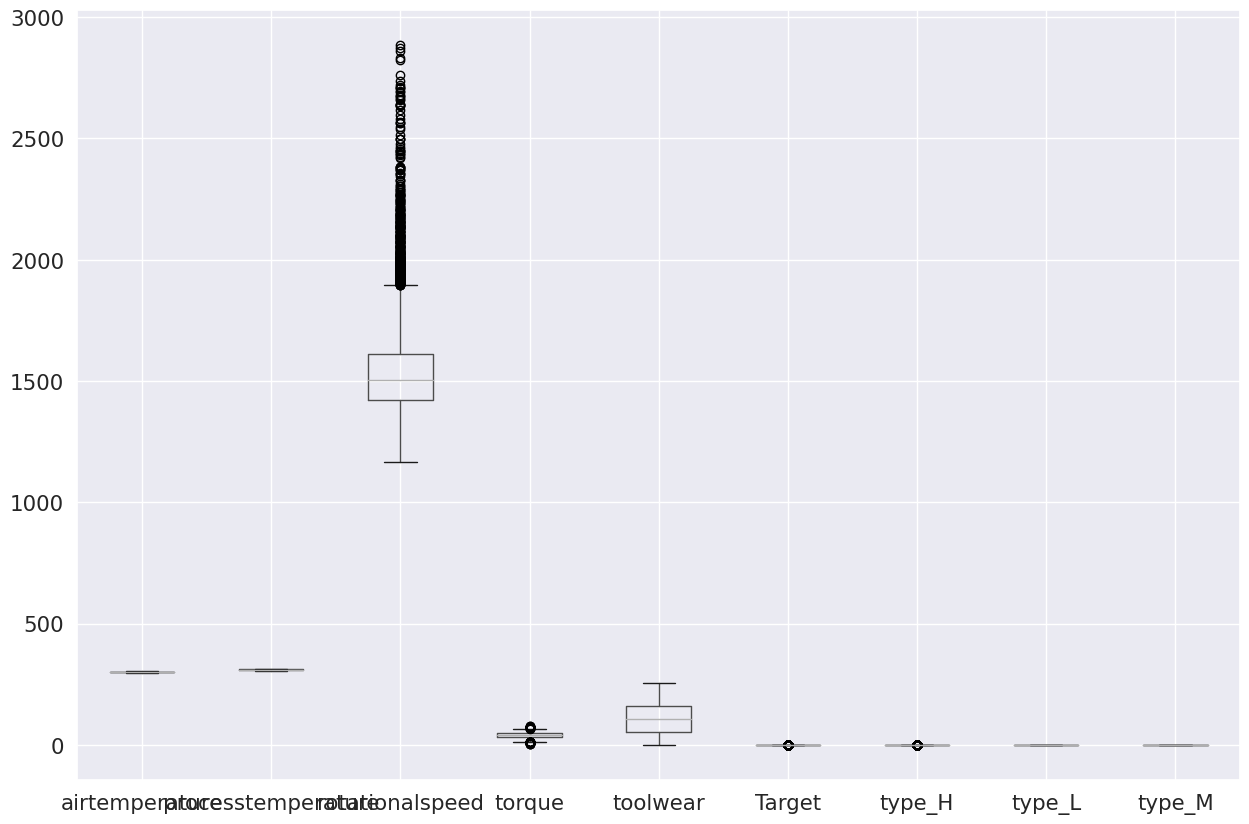

In [ ]:
#make a distribution for each column
defect_df.boxplot(figsize=(15,10))
plt.show()

<Axes: xlabel='Target', ylabel='rotationalspeed'>

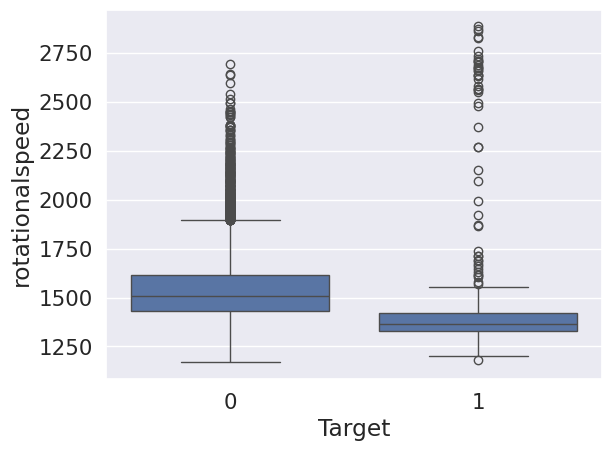

In [ ]:
#check outliers of rotational speed
sns.boxplot(x='Target',y='rotationalspeed',data=defect_df)


<ipython-input-87-bbb2d064f2e6>:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




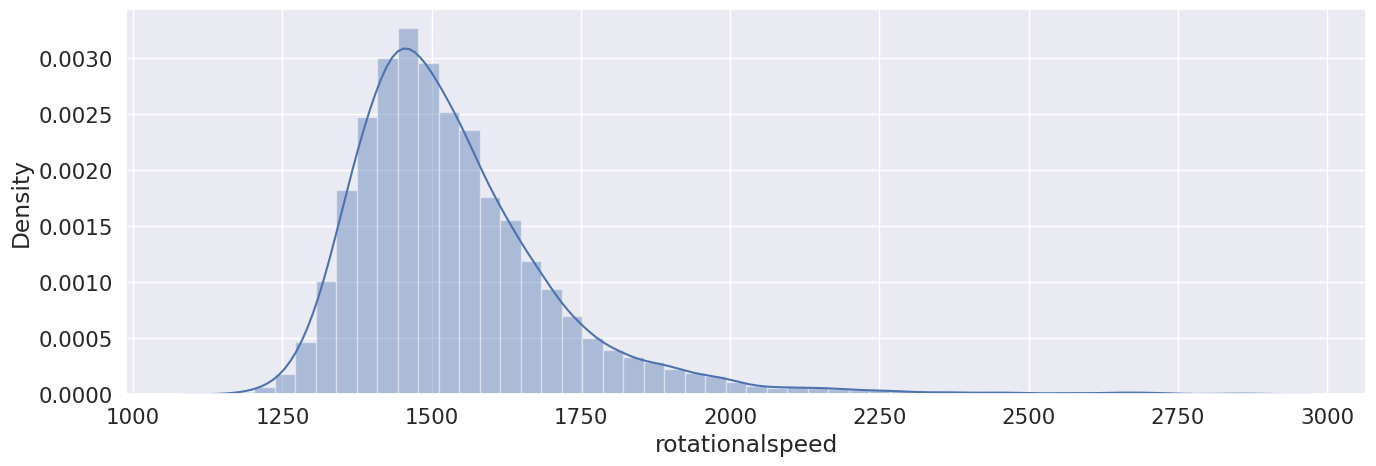

In [ ]:
plt.figure(figsize=(16,5))
sns.distplot(defect_df['rotationalspeed'])
plt.show()

<ipython-input-89-d6e78f952e69>:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




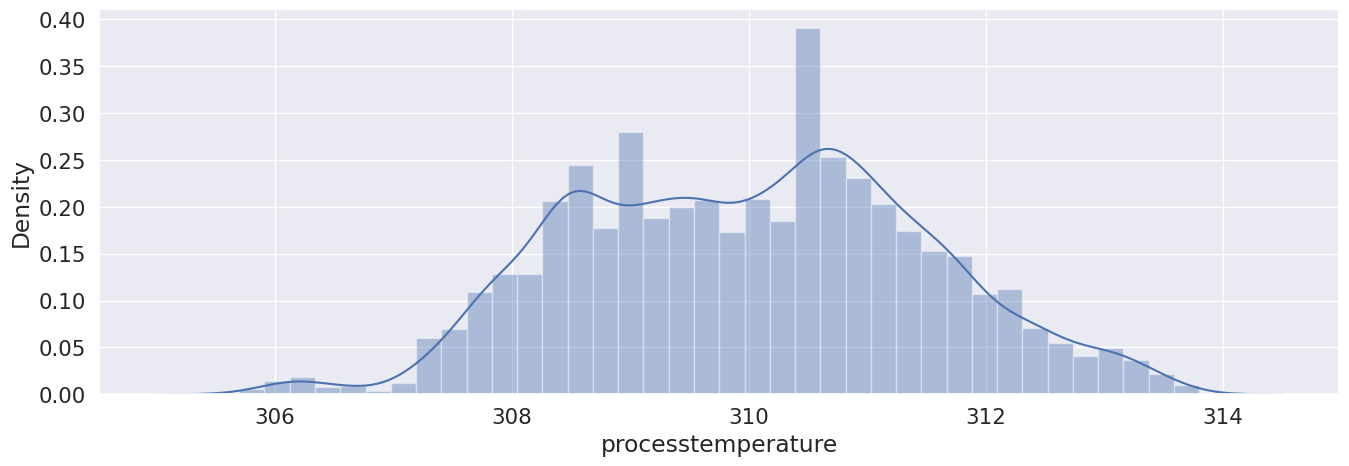

In [ ]:
plt.figure(figsize=(16,5))
sns.distplot(defect_df['processtemperature'])
plt.show()

<ipython-input-88-3cd74227e4f6>:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




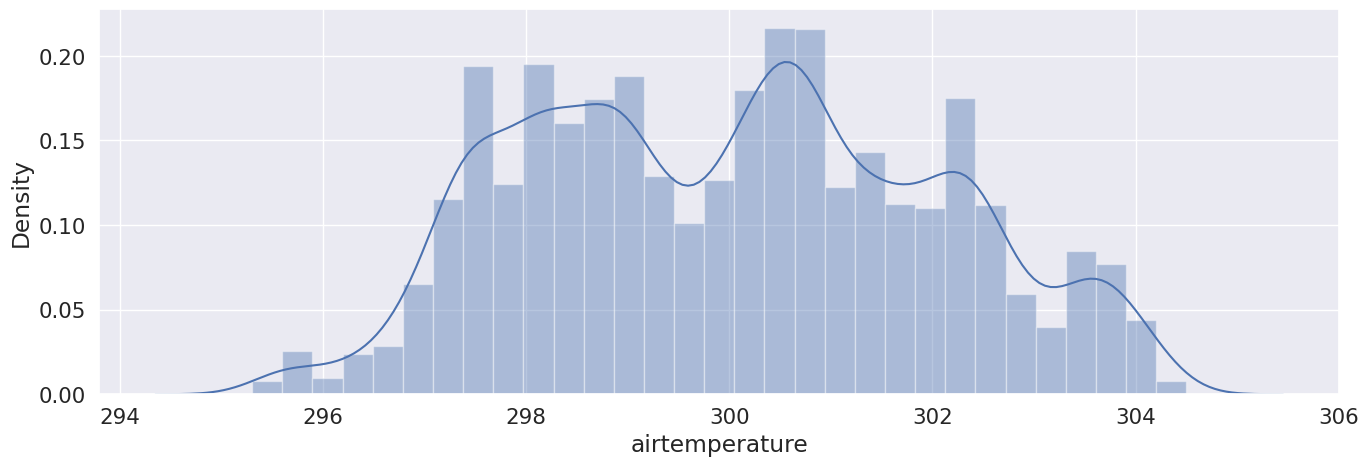

In [ ]:
plt.figure(figsize=(16,5))
sns.distplot(defect_df['airtemperature'])
plt.show()

In [ ]:
defect_df.corr()

,airtemperature,processtemperature,rotationalspeed,torque,toolwear,Target,type_H,type_L,type_M
airtemperature,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,-0.023025,0.006676,0.007958
processtemperature,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,-0.017967,0.005564,0.005831
rotationalspeed,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,-0.001171,0.004735,-0.004296
torque,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.004978,0.001191,0.001991
toolwear,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,-0.002787,0.008232,-0.006976
Target,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,-0.023916,0.035643,-0.022432
type_H,-0.023025,-0.017967,-0.001171,-0.004978,-0.002787,-0.023916,1.000000,-0.408928,-0.218425
type_L,0.006676,0.005564,0.004735,0.001191,0.008232,0.035643,-0.408928,1.000000,-0.801211
type_M,0.007958,0.005831,-0.004296,0.001991,-0.006976,-0.022432,-0.218425,-0.801211,1.000000


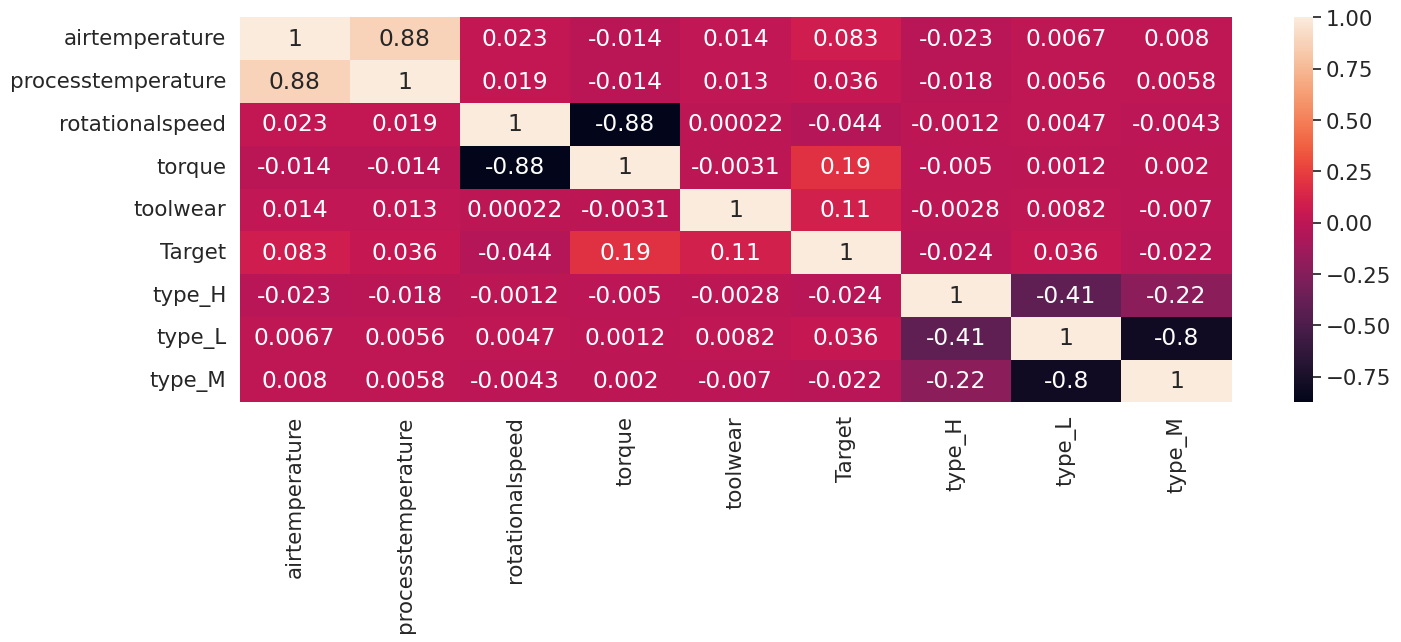

In [ ]:
#plot the correlational matrix
plt.figure(figsize=(16,5))
sns.heatmap(defect_df.corr(),annot=True)
plt.show()

Solve classification problem using Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
defect_df.head()
defect_df = defect_df.drop(['type_H','type_L','type_M'], axis=1)
defect_df.head()

,airtemperature,processtemperature,rotationalspeed,torque,toolwear,Target
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0


In [ ]:
#identify the x and y
X = defect_df.drop('Target', axis=1)
y = defect_df['Target']

In [ ]:
X

,airtemperature,processtemperature,rotationalspeed,torque,toolwear
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9
...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14
9996,298.9,308.4,1632,31.8,17
9997,299.0,308.6,1645,33.4,22
9998,299.0,308.7,1408,48.5,25


In [ ]:
y

,Target
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.20, random_state=42)

In [ ]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train,y_train)


LogisticRegression()

In [ ]:
print("test accuracy {}".format(logistic_model.score(X_test,y_test)))

test accuracy 0.9725


In [ ]:
predictions = logistic_model.predict(X_test)

Evaluate the model using classification report, accuracy and confusion matrix

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1939
           1       0.62      0.26      0.37        61

    accuracy                           0.97      2000
   macro avg       0.80      0.63      0.68      2000
weighted avg       0.97      0.97      0.97      2000



In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [ ]:
print(accuracy_score(y_test, predictions))

0.9725


In [ ]:
confusion_matrix(y_test, predictions)

array([[1929,   10],
       [  45,   16]])

<Axes: xlabel='Predicted', ylabel='Actual'>

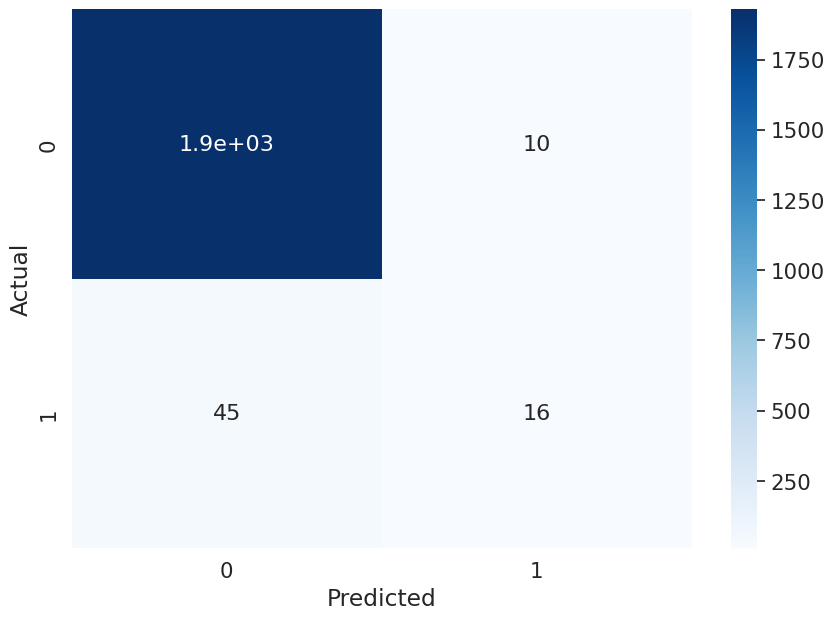

In [ ]:
data = confusion_matrix(y_test, predictions)
df_cm = pd.DataFrame(data, columns=np.unique(y_test), index = np.unique(predictions))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 16})

The model exhibits strong performance in predicting "No Failure" but struggles to accurately identify "Failure" instances. This might be due to class imbalance or the complexity of predicting failures.

Conclusion:

<font color= blue> Logistic regression, when applied to the Titanic dataset, provides valuable insights into the factors influencing survival. By analyzing the classification report and confusion matrix, we can assess the model's performance in predicting passenger survival based on various features. Key insights from the analysis include the importance of passenger class, gender, and age in determining survival outcomes. Understanding these factors can inform future research and decision-making related to disaster preparedness and response. The evaluation of the model using classification report and confusion matrix is crucial for assessing its accuracy, identifying areas for improvement, and ensuring its reliability in making predictions.</font>